# 2. Machine Learning for Regression

In [127]:
import pandas as pd
import numpy as np
from pathlib import Path

# 2.2 Data Preparation

In [128]:
base_path = Path.cwd()
file_path = base_path / "data" / "car_fuel_efficiency.csv"
df_original = pd.read_csv(file_path)

In [129]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   str    
 7   fuel_type            9704 non-null   str    
 8   drivetrain           9704 non-null   str    
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), str(3)
memory usage: 834.1 KB


In [130]:
df_original.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


#### Columns to be used:

- 'engine_displacement',
- 'horsepower',
- 'vehicle_weight',
- 'model_year',
- 'fuel_efficiency_mpg'

In [131]:
# columns to be used
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_original[columns]

In [132]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


In [133]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight         float64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

# 2.3 Exploratory data analysis

In [134]:
for col in df.columns:
    print(f'{col} : \n')
    print (df[col].unique()[:5])
    print('-'*100)
    print(df[col].nunique())
    print('-'*100)
    print()

engine_displacement : 

[170 130 220 210 190]
----------------------------------------------------------------------------------------------------
36
----------------------------------------------------------------------------------------------------

horsepower : 

[159.  97.  78.  nan 140.]
----------------------------------------------------------------------------------------------------
192
----------------------------------------------------------------------------------------------------

vehicle_weight : 

[3413.43375861 3149.66493422 3079.03899737 2542.39240183 3460.87098999]
----------------------------------------------------------------------------------------------------
9704
----------------------------------------------------------------------------------------------------

model_year : 

[2003 2007 2018 2009 2008]
----------------------------------------------------------------------------------------------------
24
------------------------------------------------------

In [135]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


### Distribution of Target Variable "fuel_efficiency_mpg"

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# configures the Matplotlib backend so that all generated figures appear immediately below the code cell that produced them.
%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

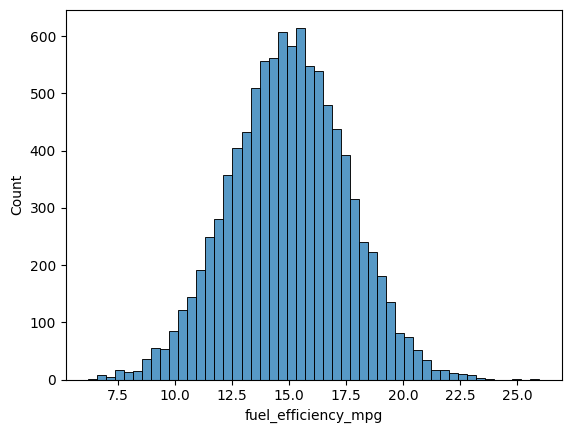

In [137]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

<Axes: ylabel='fuel_efficiency_mpg'>

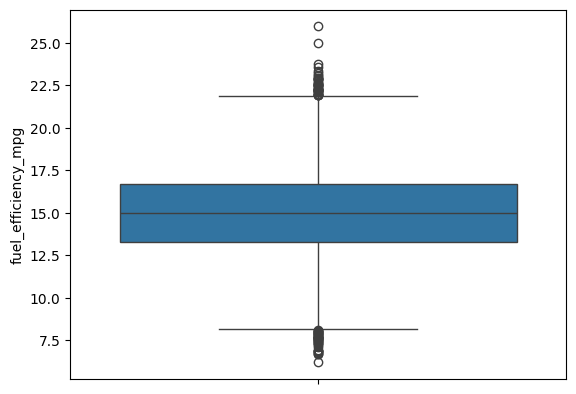

In [138]:
sns.boxplot(df.fuel_efficiency_mpg)

#### Target variable ('fuel_efficiency_mpg') follows a normal distribution with no skewness.

In [139]:
df.isnull().sum() # column with missing values

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [140]:
# Median (50% percentile) for variable 'horsepower'
df.horsepower.median()

np.float64(149.0)

# 2.4 Setting up the validation Framework

<div style="width:60%; margin-left:40px; font-size:28px;">

| Dataset Split | Percentage | Features | Target |
|---------------|------------|----------|--------|
| Train         | 60%        | $X_{train}$ | $y_{train}$ |
| Validation    | 20%        | $X_{val}$ | $y_{val}$ |
| Test          | 20%        | $X_{test}$ | $y_{test}$ |

</div>

In [141]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


### Splitting the dataset

In [142]:
# total records
n =len(df)

# data set split
n_valid = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - sum([n_valid, n_test])

print(f'Total Records : {n}')
print(f'Train + Validation + Test Records Total: {n_train + n_valid + n_test}')

Total Records : 9704
Train + Validation + Test Records Total: 9704


In [143]:
n_train, n_valid, n_test

(5824, 1940, 1940)

#### Shuffle dataset

In [144]:
index = np.arange(n)

np.random.seed(42)
np.random.shuffle(index)

In [145]:
index

array([ 483, 7506, 8795, ..., 5390,  860, 7270], shape=(9704,))

In [146]:
train_split = index[: n_train]               # 60% for training by index
val_split = index[n_train:n_train + n_valid] # 20 % validation by index
test_split = index[n_train + n_valid:]       # 20% test by index

In [147]:
df_train = df.iloc[train_split] # train split, 60%
df_val = df.iloc[val_split]     # validation split, 20%
df_test = df.iloc[test_split]   # test split, 20%

In [148]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209


In [149]:
# confirmation of number of records in the newly created splits
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [150]:
# reset indices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [151]:
# target Variable Partitions / Splits
y_train = df_train.fuel_efficiency_mpg.values
y_valid = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

#### Remove target variable from the train, validation and test data partitions

In [152]:
# drop target variable from the dataset
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# 2.5 Linear Regression

#### Dot product of a matrix

$$
\large
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\begin{bmatrix}
e & f \\
g & h
\end{bmatrix}
=
\begin{bmatrix}
ae + bg & af + bh \\
ce + dg & cf + dh
\end{bmatrix}
$$

In [153]:
def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        # res = res + w[j] * xi[j]   # see below formula
        res += w[j] * xi[j]
    return res

# 2.6 Linear regression: Vector form

The prediction vector is the result of the matrix-vector product:

$$\large \mathbf{X}\mathbf{w} = \hat{\mathbf{y}}$$

$$\large \begin{bmatrix} 
1 & x_{1,1} & \dots & x_{1,n} \\ 
1 & x_{2,1} & \dots & x_{2,n} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
1 & x_{m,1} & \dots & x_{m,n} 
\end{bmatrix} 
\begin{bmatrix} w_0 \\ w_1 \\ \vdots \\ w_n \end{bmatrix} = 
\begin{bmatrix} \mathbf{x}_1^\top \mathbf{w} \\ \mathbf{x}_2^\top \mathbf{w} \\ \vdots \\ \mathbf{x}_m^\top \mathbf{w} \end{bmatrix}$$


* **$\large\mathbf{X}$**: Design Matrix $m \times (n+1)$
* **$\large\mathbf{w}$**: Weights Vector $(n+1) \times 1$
* **$\large\hat{\mathbf{y}}$**: Predictions (PRED) $m \times 1$

# 2.7 Training a linear regression model

### Linear Regression Normal Equation

The closed-form solution for Linear Regression weights is:
$$
\large
(X^T X)^{-1} X^T X w =  (X^T X)^{-1} X^T y
$$

$$
\large
w = (X^T X)^{-1} X^T y
$$

where:

- ($X$) is the **design matrix** (features)
- ($X^T$) is the **transpose of \(X\)**
- ($y$) is the **target vector**
- ($w$) is the **weight vector**

In [154]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86]
    
    
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [155]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0]) # Bias term vector values
    X = np.column_stack([ones, X])  # adds 1's to the 1st column of X

    # Gram Matrix
    
    # XTX_inv.dot(XTX).round(1) # should give an identity matrix
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y) # Calculation of the weight formula

    w_0 = w_full[0] # bias term
    w = w_full[1:]  # weights

    return w_0, w

# 2.8 Fuel efficiency baseline model

In [156]:
df_train.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight         float64
model_year               int64
dtype: object

In [157]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

### Missing Values

In [158]:
df_train.isnull().sum()

engine_displacement      0
horsepower             429
vehicle_weight           0
model_year               0
dtype: int64

#### With '0' as Replacement value

In [159]:
X_train = df_train.fillna(0).isnull().sum()

In [160]:
X_train

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [161]:
X_train = df_train.fillna(0).values
X_train

array([[ 220.        ,  144.        , 2535.88759124, 2009.        ],
       [ 160.        ,  141.        , 2741.17048439, 2019.        ],
       [ 230.        ,  155.        , 2471.88023726, 2017.        ],
       ...,
       [ 210.        ,  152.        , 2500.17568746, 2020.        ],
       [ 250.        ,  154.        , 2254.31324473, 2002.        ],
       [ 210.        ,  152.        , 2435.20360628, 2004.        ]],
      shape=(5824, 4))

In [162]:
w0, w = train_linear_regression(X_train, y_train)

In [167]:
# prediction results
y_pred = w0 + X_train.dot(w)

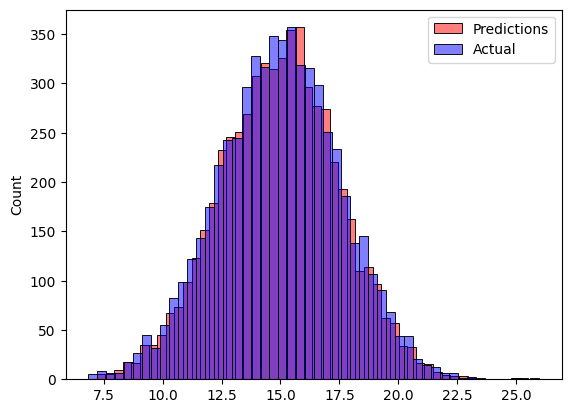

In [168]:
sns.histplot(y_pred, color='red',alpha=0.5, bins=50, label='Predictions')
sns.histplot(y_train, color='blue',alpha=0.5,  bins=50, label='Actual')
plt.legend()

#### With mean as Replacement value

In [163]:
df_train.fillna(df_train.mean(numeric_only=True)).isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [170]:
X_train = df_train.fillna(df_train.mean(numeric_only=True)).values
X_train

array([[ 220.        ,  144.        , 2535.88759124, 2009.        ],
       [ 160.        ,  141.        , 2741.17048439, 2019.        ],
       [ 230.        ,  155.        , 2471.88023726, 2017.        ],
       ...,
       [ 210.        ,  152.        , 2500.17568746, 2020.        ],
       [ 250.        ,  154.        , 2254.31324473, 2002.        ],
       [ 210.        ,  152.        , 2435.20360628, 2004.        ]],
      shape=(5824, 4))

In [ ]:
w_0, w = train_linear_regression(X_train, y_train)

# 2.9 RMSE

### Root Mean Squared Error (RMSE)

The **Root Mean Squared Error** measures the average magnitude of prediction errors in a regression model.

$$
\large
RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left(g(x_i) - y_i \right)^2}
$$

---

## Variables

- $m$ : Number of observations (samples) in the dataset  
- $x_i$ : Feature vector for the $i^{th}$ observation  
- $g(x_i)$ : Model prediction for $x_i$  
- $y_i$ : Actual (true) target value for the $i^{th}$ observation  
- $g(x_i) - y_i$ : Prediction error (residual)  
- $(g(x_i) - y_i)^2$ : Squared error for observation $i$ 

---

## Interpretation

RMSE computes the square root of the **average squared difference between predictions and actual values**.

- Smaller RMSE → Better model fit  
- Larger RMSE → Predictions are further from the true values

RMSE has the **same units as the target variable**, which makes it easier to interpret compared to MSE.